In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/processed_logistics_data.csv",
    encoding="latin1"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 180519
Columns: 58


C:\Users\Jayita\AppData\Local\Temp\ipykernel_15940\1702499778.py:6: DtypeWarning: Columns (19: Customer Zipcode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [2]:
df["order date (DateOrders)"] = pd.to_datetime(
    df["order date (DateOrders)"],
    errors="coerce"
)

df["shipping date (DateOrders)"] = pd.to_datetime(
    df["shipping date (DateOrders)"],
    errors="coerce"
)

print(df[[
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]].dtypes)

order date (DateOrders)       datetime64[us]
shipping date (DateOrders)    datetime64[us]
dtype: object


In [3]:
df["order_month_period"] = (
    df["order date (DateOrders)"]
    .dt.to_period("M")
)

df["order_month"] = (
    df["order date (DateOrders)"]
    .dt.month
)

df["order_year"] = (
    df["order date (DateOrders)"]
    .dt.year
)

df["order_month_name"] = (
    df["order date (DateOrders)"]
    .dt.strftime("%b")
)

In [4]:
print("===== DATASET OVERVIEW =====")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n===== DATA TYPES =====")
print(df.dtypes)

print("\n===== DESCRIPTIVE STATISTICS =====")
print(
    df[
        [
            "Days for shipping (real)",
            "Days for shipment (scheduled)",
            "Order Item Quantity",
            "Order Item Product Price",
            "Order Item Total",
            "Order Profit Per Order",
            "schedule_deviation"
        ]
    ].describe()
)

===== DATASET OVERVIEW =====
Rows: 180519
Columns: 59

===== DATA TYPES =====
Type                                        str
Days for shipping (real)                  int64
Days for shipment (scheduled)             int64
Benefit per order                       float64
Sales per customer                      float64
Delivery Status                             str
Late_delivery_risk                        int64
Category Id                               int64
Category Name                               str
Customer City                               str
Customer Country                            str
Customer Email                              str
Customer Fname                              str
Customer Id                               int64
Customer Lname                              str
Customer Password                           str
Customer Segment                            str
Customer State                              str
Customer Street                             str
Customer Z

In [5]:
monthly_orders = (
    df.groupby("order_month_period")["Order Id"]
    .nunique()
    .reset_index(name="order_count")
)

monthly_orders.head()

,order_month_period,order_count
0,2015-01,1787
1,2015-02,1585
2,2015-03,1781
3,2015-04,1710
4,2015-05,1776


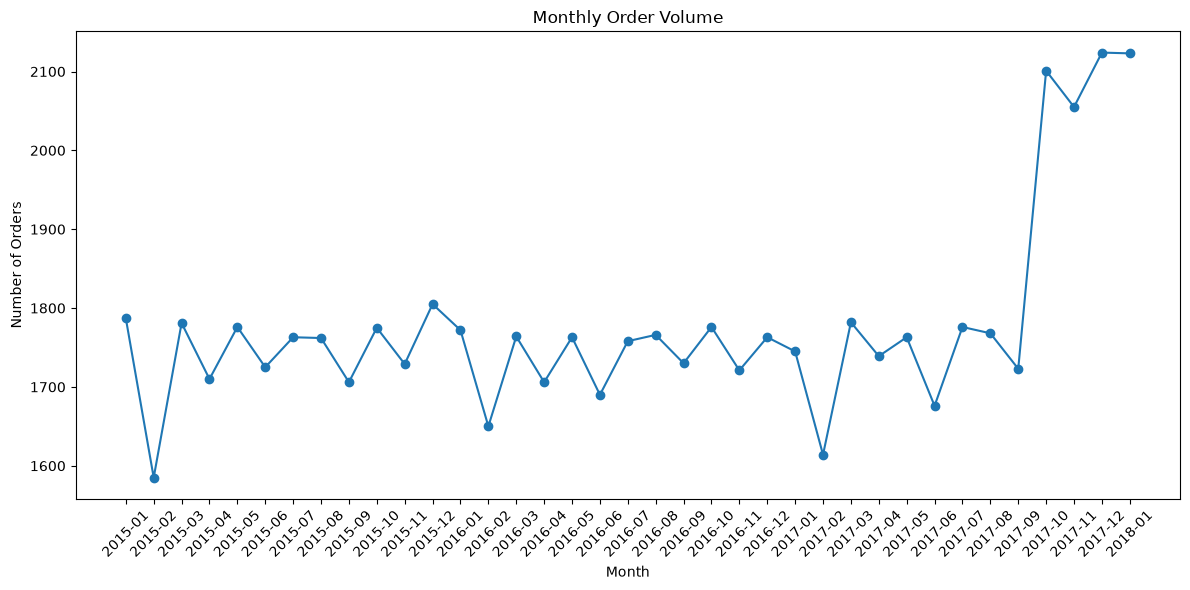

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_orders["order_month_period"].astype(str),
    monthly_orders["order_count"],
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../visualizations/monthly_order_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
monthly_sales = (
    df.groupby("order_month_period")["Order Item Total"]
    .sum()
    .reset_index(name="total_sales")
)

monthly_sales.head()

,order_month_period,total_sales
0,2015-01,945382.160534
1,2015-02,833012.429253
2,2015-03,944050.110472
3,2015-04,912004.400261
4,2015-05,943939.769956


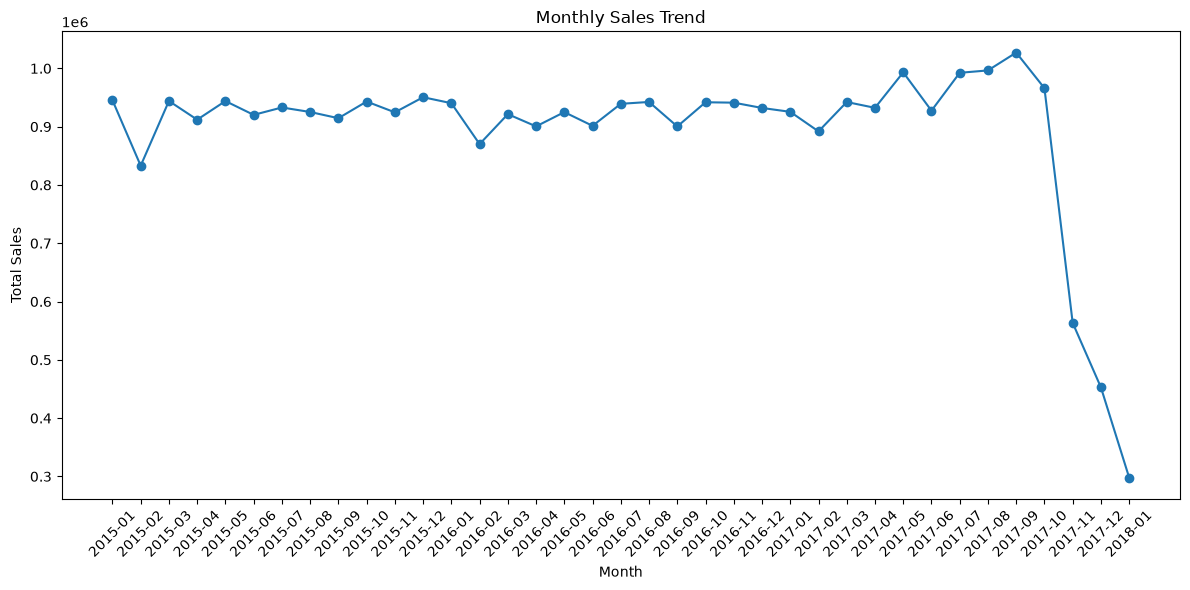

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["order_month_period"].astype(str),
    monthly_sales["total_sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../visualizations/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

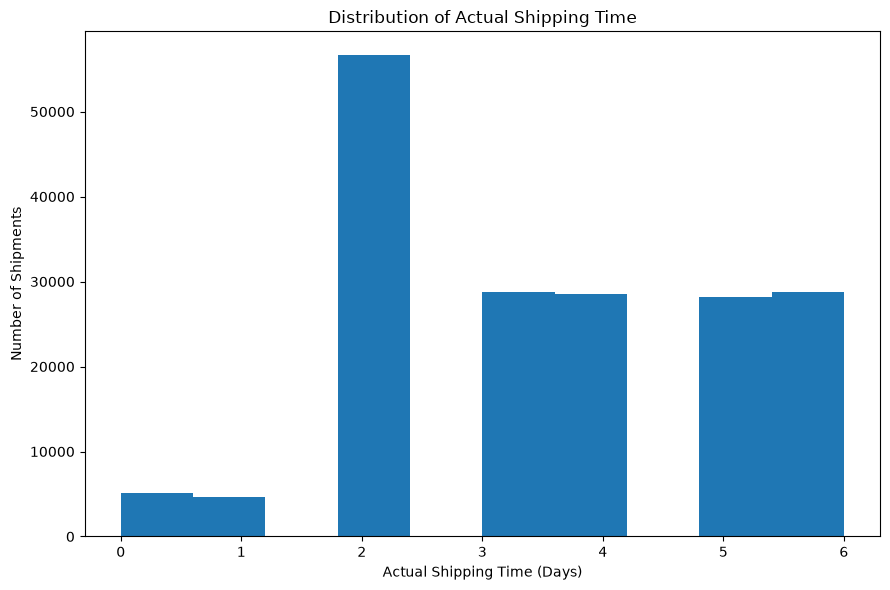

In [9]:
plt.figure(figsize=(9, 6))

plt.hist(
    df["Days for shipping (real)"],
    bins=10
)

plt.title("Distribution of Actual Shipping Time")
plt.xlabel("Actual Shipping Time (Days)")
plt.ylabel("Number of Shipments")

plt.tight_layout()

plt.savefig(
    "../visualizations/shipping_time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

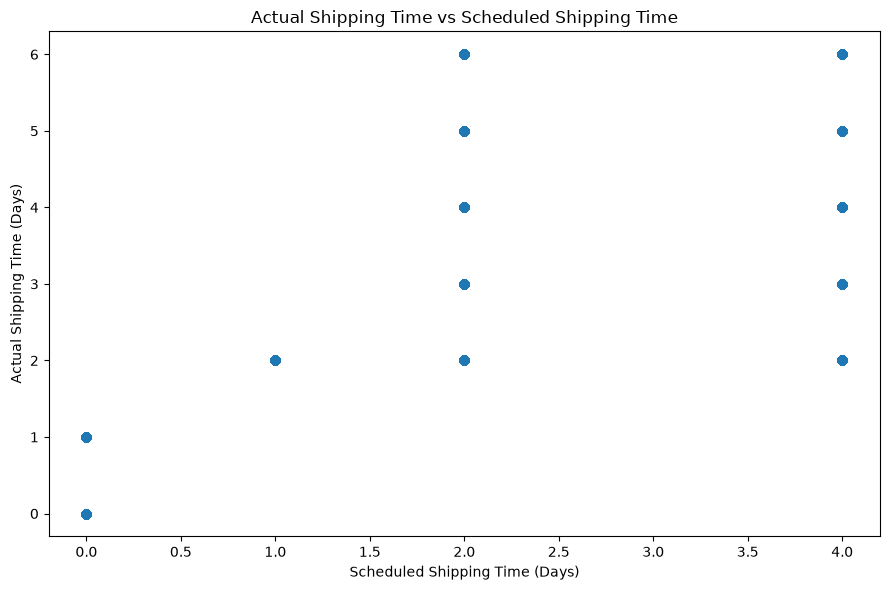

In [10]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Days for shipment (scheduled)"],
    df["Days for shipping (real)"],
    alpha=0.2
)

plt.title("Actual Shipping Time vs Scheduled Shipping Time")
plt.xlabel("Scheduled Shipping Time (Days)")
plt.ylabel("Actual Shipping Time (Days)")

plt.tight_layout()

plt.savefig(
    "../visualizations/actual_vs_scheduled_shipping.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
regional_analysis = (
    df.groupby("Order Region")
    .agg(
        shipments=("Order Id", "count"),
        avg_shipping_days=("Days for shipping (real)", "mean"),
        avg_schedule_deviation=("schedule_deviation", "mean"),
        late_risk_rate=("Late_delivery_risk", "mean"),
        total_sales=("Order Item Total", "sum")
    )
    .reset_index()
)

regional_analysis["late_risk_rate"] *= 100

regional_analysis = regional_analysis.sort_values(
    "late_risk_rate",
    ascending=False
)

regional_analysis.head(10)

,Order Region,shipments,avg_shipping_days,avg_schedule_deviation,late_risk_rate,total_sales
2,Central Africa,1677,3.560525,0.639833,57.960644,2.929126e+05
13,South Asia,7731,3.502005,0.597465,56.266977,1.397365e+06
5,East Africa,1852,3.514579,0.570734,55.939525,3.380543e+05
22,Western Europe,27109,3.498432,0.597403,55.848611,5.296003e+06
14,South of USA,4045,3.492707,0.579975,55.772559,7.069043e+05
8,Eastern Europe,3920,3.500765,0.579847,55.663265,6.963072e+05
6,East of USA,6915,3.500940,0.584816,55.661605,1.231955e+06
15,Southeast Asia,9539,3.496698,0.558235,55.529930,1.738553e+06
4,Central Asia,553,3.417722,0.645570,55.334539,9.795369e+04
20,West Asia,6009,3.486770,0.569479,55.283741,1.056081e+06


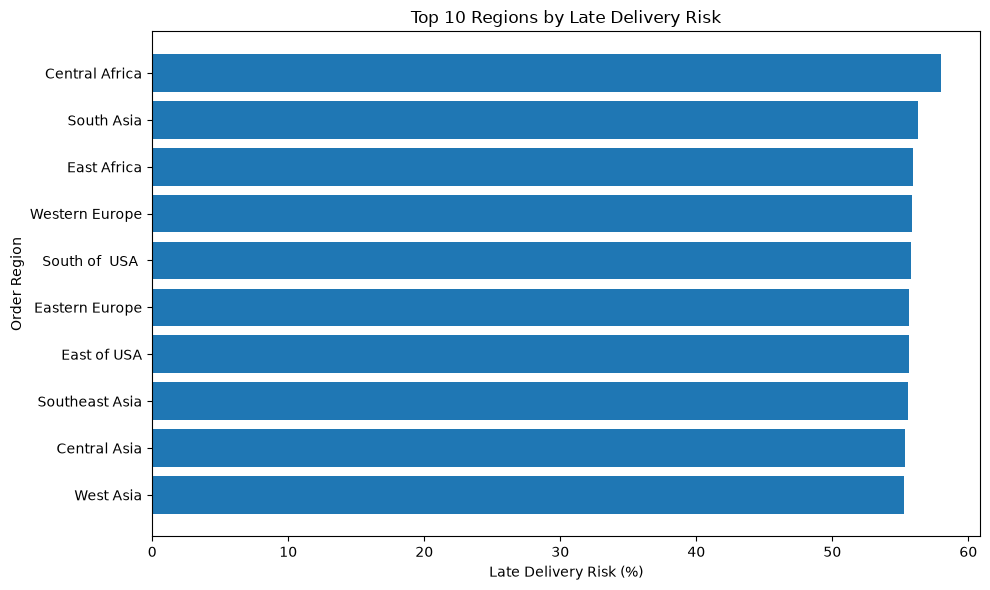

In [12]:
top_regions = regional_analysis.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_regions["Order Region"],
    top_regions["late_risk_rate"]
)

plt.title("Top 10 Regions by Late Delivery Risk")
plt.xlabel("Late Delivery Risk (%)")
plt.ylabel("Order Region")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../visualizations/week3_top_regions_late_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
shipping_analysis = (
    df.groupby("Shipping Mode")
    .agg(
        shipments=("Order Id", "count"),
        avg_actual_days=("Days for shipping (real)", "mean"),
        avg_scheduled_days=("Days for shipment (scheduled)", "mean"),
        avg_schedule_deviation=("schedule_deviation", "mean"),
        late_risk_rate=("Late_delivery_risk", "mean"),
        total_sales=("Order Item Total", "sum"),
        avg_profit=("Order Profit Per Order", "mean")
    )
    .reset_index()
)

shipping_analysis["late_risk_rate"] *= 100

shipping_analysis

,Shipping Mode,shipments,avg_actual_days,avg_scheduled_days,avg_schedule_deviation,late_risk_rate,total_sales,avg_profit
0,First Class,27814,2.000000,1.0,1.000000,95.322499,5.100451e+06,23.122238
1,Same Day,9737,0.478279,0.0,0.478279,45.743042,1.745202e+06,20.850203
2,Second Class,35216,3.990828,2.0,1.990828,76.632781,6.416529e+06,21.305889
3,Standard Class,107752,3.995907,4.0,-0.004093,38.071683,1.979222e+07,21.999169


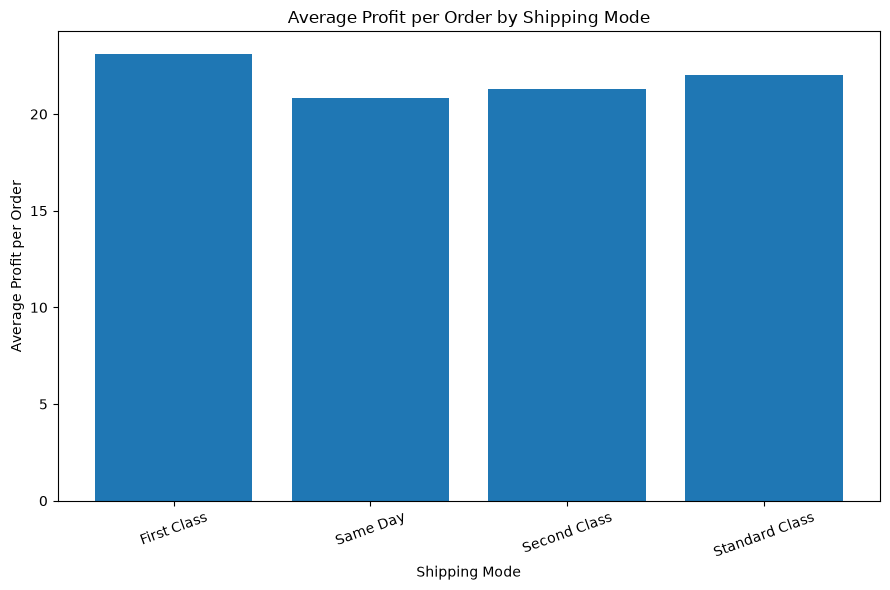

In [16]:
plt.figure(figsize=(9, 6))

plt.bar(
    shipping_analysis["Shipping Mode"],
    shipping_analysis["avg_profit"]
)

plt.title("Average Profit per Order by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Profit per Order")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../visualizations/profit_by_shipping_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
shipping_analysis = (
    df.groupby("Shipping Mode")
    .agg(
        shipments=("Order Id", "count"),
        avg_actual_days=("Days for shipping (real)", "mean"),
        avg_scheduled_days=("Days for shipment (scheduled)", "mean"),
        avg_schedule_deviation=("schedule_deviation", "mean"),
        late_risk_rate=("Late_delivery_risk", "mean"),
        total_sales=("Order Item Total", "sum"),
        avg_profit=("Order Profit Per Order", "mean")
    )
    .reset_index()
)

shipping_analysis["late_risk_rate"] *= 100

shipping_analysis = shipping_analysis.round(2)

shipping_analysis

,Shipping Mode,shipments,avg_actual_days,avg_scheduled_days,avg_schedule_deviation,late_risk_rate,total_sales,avg_profit
0,First Class,27814,2.00,1.0,1.00,95.32,5100451.07,23.12
1,Same Day,9737,0.48,0.0,0.48,45.74,1745201.53,20.85
2,Second Class,35216,3.99,2.0,1.99,76.63,6416528.54,21.31
3,Standard Class,107752,4.00,4.0,-0.00,38.07,19792221.24,22.00


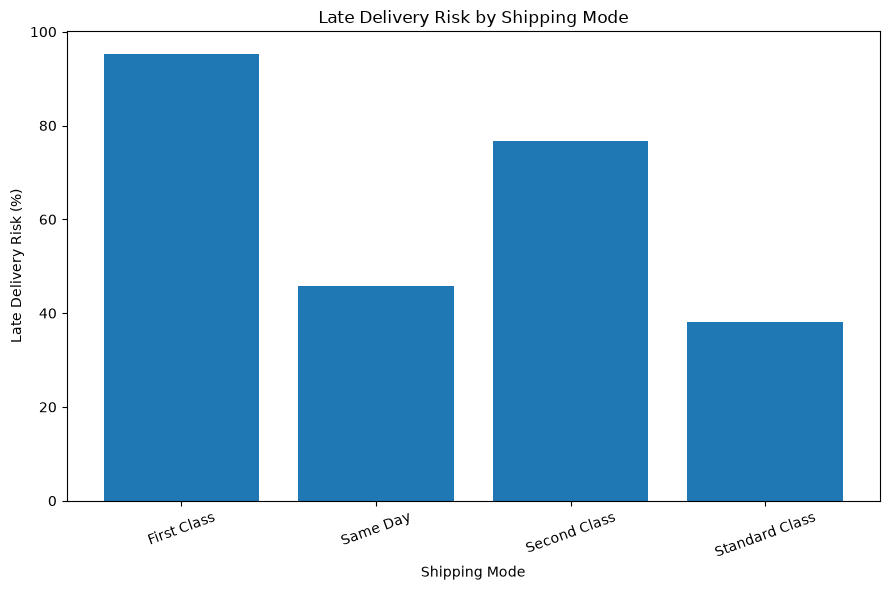

In [23]:
plt.figure(figsize=(9, 6))

plt.bar(
    shipping_analysis["Shipping Mode"],
    shipping_analysis["late_risk_rate"]
)

plt.title("Late Delivery Risk by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Late Delivery Risk (%)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../visualizations/week3_shipping_mode_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Total Sales",
        "Average Shipping Time",
        "Average Scheduled Shipping Time",
        "Average Schedule Deviation",
        "Average Order Quantity",
        "Average Product Price",
        "Average Order Profit",
        "Late Delivery Risk Rate"
    ],
    "Value": [
        df["Order Id"].nunique(),
        round(df["Order Item Total"].sum(), 2),
        round(df["Days for shipping (real)"].mean(), 2),
        round(df["Days for shipment (scheduled)"].mean(), 2),
        round(df["schedule_deviation"].mean(), 2),
        round(df["Order Item Quantity"].mean(), 2),
        round(df["Order Item Product Price"].mean(), 2),
        round(df["Order Profit Per Order"].mean(), 2),
        round(df["Late_delivery_risk"].mean() * 100, 2)
    ]
})

eda_summary

,Metric,Value
0,Total Orders,65752.00
1,Total Sales,33054402.38
2,Average Shipping Time,3.50
3,Average Scheduled Shipping Time,2.93
4,Average Schedule Deviation,0.57
5,Average Order Quantity,2.13
6,Average Product Price,141.23
7,Average Order Profit,21.97
8,Late Delivery Risk Rate,54.83


In [18]:
central_tendency = df[
    [
        "Days for shipping (real)",
        "Days for shipment (scheduled)",
        "Order Item Quantity",
        "Order Item Product Price",
        "Order Item Total",
        "Order Profit Per Order",
        "schedule_deviation"
    ]
].agg(["mean", "median", "std"]).T

central_tendency = central_tendency.round(2)

central_tendency

,mean,median,std
Days for shipping (real),3.50,3.00,1.62
Days for shipment (scheduled),2.93,4.00,1.37
Order Item Quantity,2.13,1.00,1.45
Order Item Product Price,141.23,59.99,139.73
Order Item Total,183.11,163.99,120.04
Order Profit Per Order,21.97,31.52,104.43
schedule_deviation,0.57,1.00,1.49


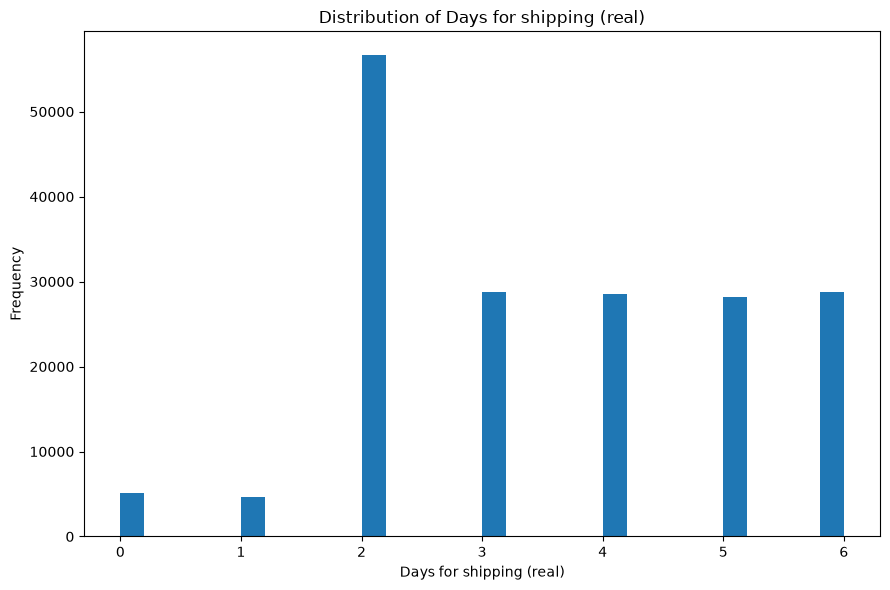

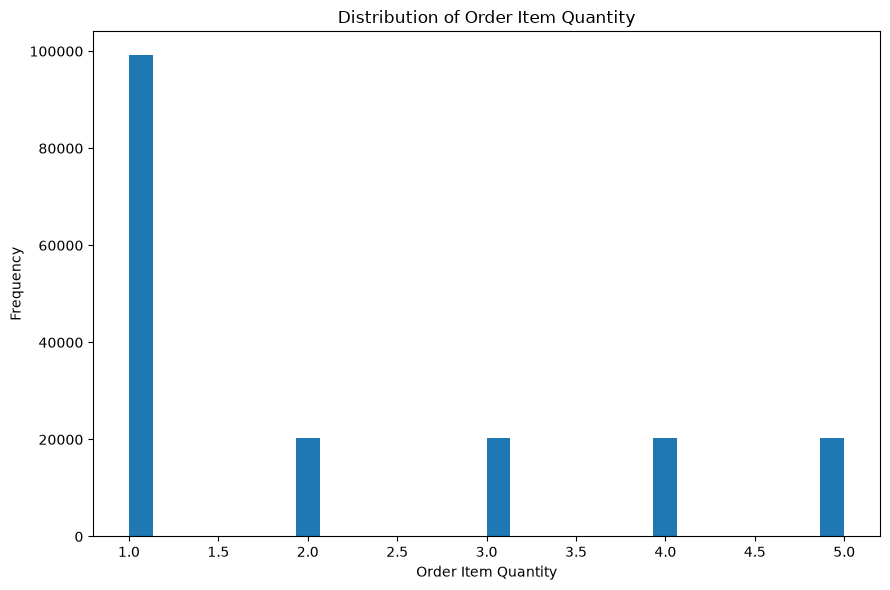

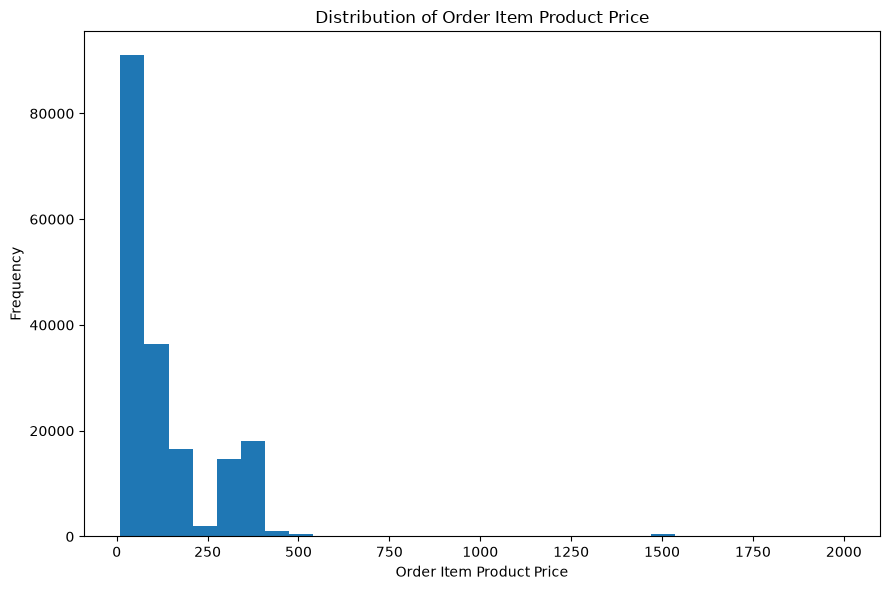

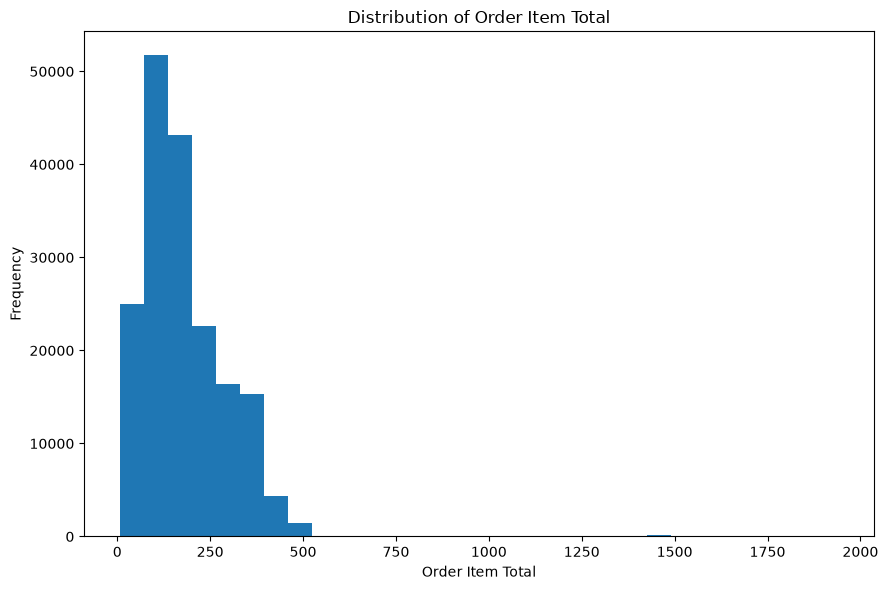

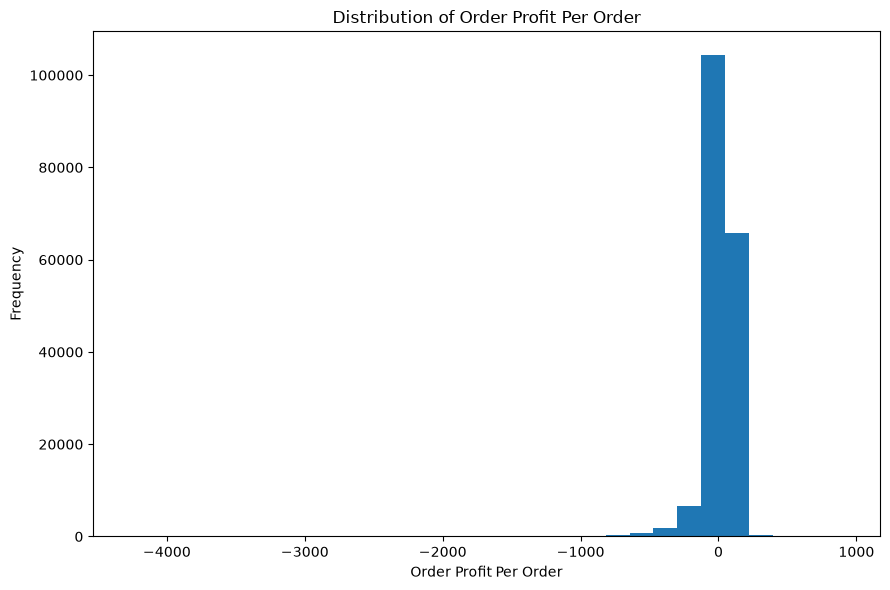

In [19]:
distribution_columns = [
    "Days for shipping (real)",
    "Order Item Quantity",
    "Order Item Product Price",
    "Order Item Total",
    "Order Profit Per Order"
]

for column in distribution_columns:

    plt.figure(figsize=(9, 6))

    plt.hist(
        df[column],
        bins=30
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()

    filename = (
        column.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )

    plt.savefig(
        f"../visualizations/distribution_{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [20]:
correlation_columns = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Order Item Quantity",
    "Order Item Product Price",
    "Order Item Discount",
    "Order Item Total",
    "Order Profit Per Order",
    "schedule_deviation",
    "Late_delivery_risk"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(2)

,Days for shipping (real),Days for shipment (scheduled),Order Item Quantity,Order Item Product Price,Order Item Discount,Order Item Total,Order Profit Per Order,schedule_deviation,Late_delivery_risk
Days for shipping (real),1.00,0.52,-0.00,0.00,0.00,0.00,-0.01,0.61,0.40
Days for shipment (scheduled),0.52,1.00,-0.00,0.01,0.00,0.01,-0.00,-0.36,-0.37
Order Item Quantity,-0.00,-0.00,1.00,-0.48,0.07,0.11,0.02,0.00,-0.00
Order Item Product Price,0.00,0.01,-0.48,1.00,0.49,0.78,0.10,-0.00,-0.00
Order Item Discount,0.00,0.00,0.07,0.49,1.00,0.50,0.06,-0.00,-0.00
Order Item Total,0.00,0.01,0.11,0.78,0.50,1.00,0.13,-0.00,-0.00
Order Profit Per Order,-0.01,-0.00,0.02,0.10,0.06,0.13,1.00,-0.01,-0.00
schedule_deviation,0.61,-0.36,0.00,-0.00,-0.00,-0.00,-0.01,1.00,0.78
Late_delivery_risk,0.40,-0.37,-0.00,-0.00,-0.00,-0.00,-0.00,0.78,1.00


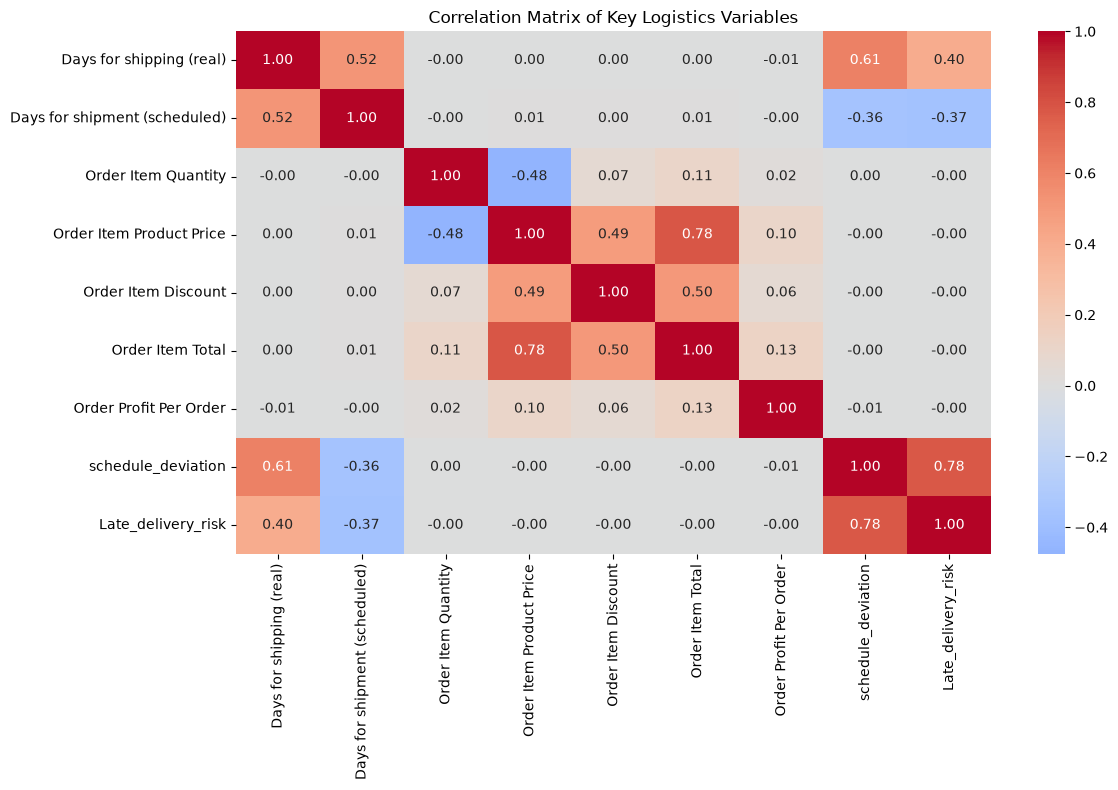

In [21]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Key Logistics Variables")

plt.tight_layout()

plt.savefig(
    "../visualizations/logistics_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()